In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import astropy.io.fits as fits
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.font_manager
import matplotlib as mpl

npix = 512 
nfreq = 401

base = '/home/ppxjf3/RSD_LC/resolution_comparison/'


column_width=240# call "\the\columnwidth" in LaTeX to find
ppi=72#default ppi, can be left the same

scale=2
fig_width=column_width/ppi*scale#inches
fig_height=3*scale#inches

##SET FONT SIZES
font_small_size = 9
font_medium_size = 12
font_bigger_size =14

plt.rc('font', size=font_small_size) # controls default text sizes
plt.rc('axes', titlesize=font_small_size) # fontsize of the axes title
plt.rc('axes', labelsize=font_medium_size) # fontsize of the x and y labels
plt.rc('xtick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('ytick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('legend', fontsize=font_small_size) # legend fontsize
plt.rc('figure', titlesize=font_bigger_size)


#correct font for MNRAS
#can be found at https://www.fontsquirrel.com/fonts/nimbus-roman-no9-l
#can be installed on Unix systems by putting unzipped folder in directory /home/{user}/.fonts
#run "fc-cache -v" in console to inform system of new font
#print(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))
#plt.rc('font', family='Nimbus Roman')
# mpl.rcParams["font.family"] = "Nimbus Roman"
# mpl.rcParams['mathtext.fontset'] = 'custom'
# mpl.rcParams['mathtext.rm'] = 'Nimbus Roman'
# mpl.rcParams['mathtext.it'] = 'Nimbus Roman:italic'
# mpl.rcParams['mathtext.bf'] = 'Nimbus Roman:bold'
"""
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rc('text', usetex=True)
"""

#DPI of MNRAS is 300
mpl.rcParams['figure.dpi'] = 300/scale
# Set up a figure with four panels, with two rows and columns#
#

from astropy.cosmology import Planck13 as cosmoP
from astropy.cosmology import FlatLambdaCDM, LambdaCDM
import astropy
import astropy.units as u
cosmo = FlatLambdaCDM(H0=71 * u.km / u.s / u.Mpc, Om0=0.27)

Define functions for use in notebook

In [2]:
def zFromNu(nu):
    """
    Convert frequency of 21cm line to redshift
    
    Input: nu [MHz]
    """
    nu21 = 1.420405e3  #MHz
    return nu21/nu - 1.0


def LC_Volume(nu_min, nu_max, FoV):
    z_lo = zFromNu(nu_min)
    z_hi = zFromNu(nu_max)
    
    r_min = cosmo.comoving_distance(z_lo)/u.Mpc
    r_max = cosmo.comoving_distance(z_hi)/u.Mpc
    height = np.abs(r_max - r_min)
    
    S1 = (r_min* (np.pi * FoV / 180.0))**2
    S2 = (r_max* (np.pi * FoV / 180.0))**2
    return (height/3)*(S1 + S2 + np.sqrt(S1*S2))

def get_lengths(nu_low, nu_hi, nu_mid, theta_FOV):
    z_lo = zFromNu(nu_low)
    z_mid = zFromNu(nu_mid)
    z_hi = zFromNu(nu_hi)
    
    L_para = cosmo.comoving_distance(z_lo) - cosmo.comoving_distance(z_hi)
    L_perp = cosmo.comoving_distance(z_mid) * (np.pi * theta_FOV / 180.0)
    return L_para/u.Mpc, L_perp/u.Mpc

def lengthscale(z, theta):
    d = ((z*(3*10**8))/cosmo.H0)/u.Mpc
    theta = theta*((2*np.pi)/180)
    return d*theta

Open all fits files needed for the resoltuion comparison

In [3]:

base = '/home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/'

with open(base+'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    RSD_1degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
RSD_1degree = np.array(RSD_1degree)*1e3
RSD_1degree = RSD_1degree.reshape(npix,npix,nfreq)

with open(base+ 'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC_1degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_1degree = np.array(LC_1degree)*1e3
LC_1degree = LC_1degree.reshape(npix,npix,nfreq)


with open(base + 'LightconeRSD_N512_FOV2.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    RSD_2degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
    
RSD_2degree = np.array(RSD_2degree)*1e3
RSD_2degree = RSD_2degree.reshape(npix,npix,nfreq)

with open(base + 'LightconeRSD_N512_FOV2.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC_2degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
    
LC_2degree = np.array(LC_2degree)*1e3
LC_2degree = LC_2degree.reshape(npix,npix,nfreq)

with open(base + 'LightconeRSD_N512_FOV3.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.005991_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    RSD_3degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
    
RSD_3degree = np.array(RSD_3degree)*1e3
RSD_3degree = RSD_3degree.reshape(npix,npix,nfreq)

with open(base + 'LightconeRSD_N512_FOV3.0000_dnu0.10MHz_180.00MHz_140.00MHz_ds0.014978_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC_3degree = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
    
LC_3degree = np.array(LC_3degree)*1e3
LC_3degree = LC_3degree.reshape(npix,npix,nfreq)

Use tools21cm to calculate the power spectrum for each resolution of lightcone

In [4]:
import tools21cm as t2c

nu = np.arange(140, 180.5, 0.1)   
i0 = 0
i1 = 101
#do power spectrum
#EoR

L_para, L_perp = get_lengths(nu[i0], nu[i1], (nu[i0]+nu[i1])/2, 3.0)
box_dims = [L_perp, L_perp, L_para]
    
p_rsd_3, k_rsd_3, n_rsd_3 = t2c.power_spectrum_1d(RSD_3degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_rsd_3 = (p_rsd_3*k_rsd_3**3)/(2*np.pi**2)
p_lc_3, k_lc_3, n_lc_3 = t2c.power_spectrum_1d(LC_3degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_lc_3 = (p_lc_3*k_lc_3**3)/(2*np.pi**2)

L_para, L_perp = get_lengths(nu[i0], nu[i1], (nu[i0]+nu[i1])/2, 2.0)
box_dims = [L_perp, L_perp, L_para]

p_rsd_2, k_rsd_2, n_rsd_2 = t2c.power_spectrum_1d(RSD_2degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_rsd_2 = (p_rsd_2*k_rsd_2**3)/(2*np.pi**2)
p_lc_2, k_lc_2, n_lc_2 = t2c.power_spectrum_1d(LC_2degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_lc_2 = (p_lc_2*k_lc_2**3)/(2*np.pi**2)


L_para, L_perp = get_lengths(nu[i0], nu[i1], (nu[i0]+nu[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

p_lc_1, k_lc_1, n_lc_1 = t2c.power_spectrum_1d(LC_1degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_lc_1 = (p_lc_1*k_lc_1**3)/(2*np.pi**2)

p_rsd_1, k_rsd_1, n_rsd_1 = t2c.power_spectrum_1d(RSD_1degree[:,:,i0:i1], kbins=15, box_dims=box_dims, binning = 'logarithmic', return_n_modes=True)
d_rsd_1 = (p_rsd_1*k_rsd_1**3)/(2*np.pi**2)

In [5]:
print(d_lc_3[0])
print(k_lc_3[0])

print(d_lc_2[0])
print(k_lc_2[0])

print(d_lc_1[0])
print(k_lc_1[0])

6.403383773680361
0.08266019757736842
4.653783623129205
0.06789239008785874
5.460259365538389
0.08170927985012014


Create graph for the resolution comparison section of the paper

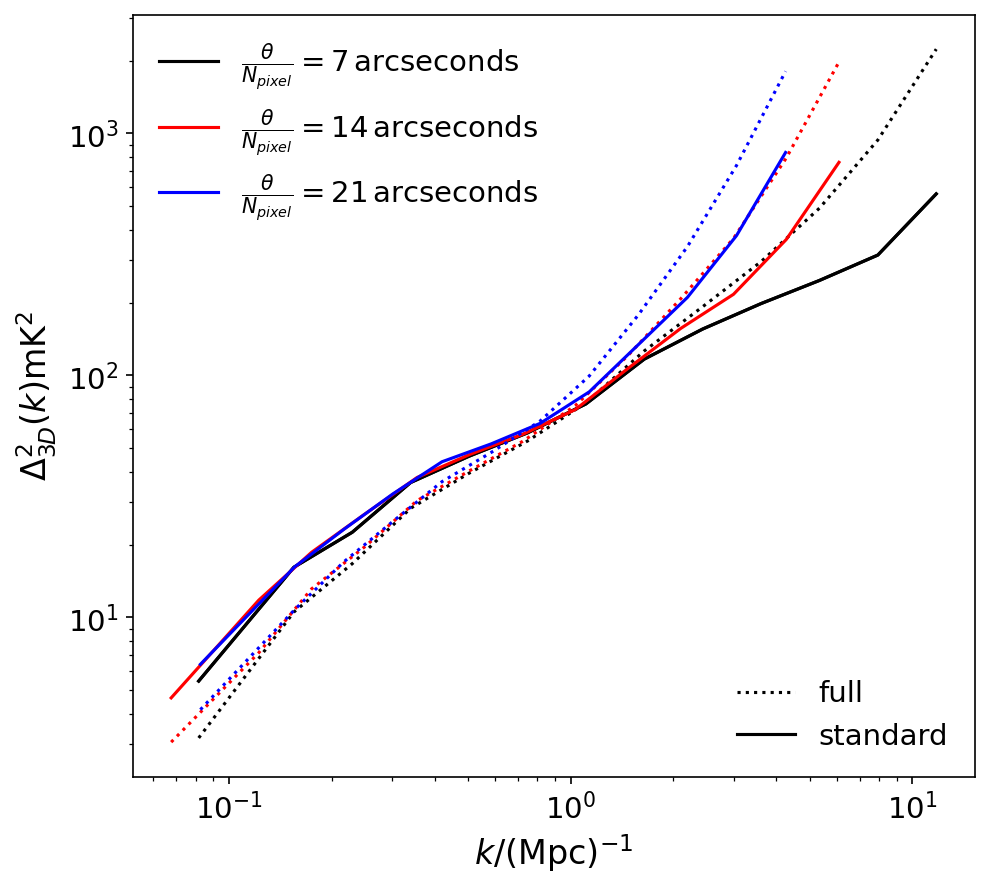

In [6]:
#calculate errors
err_lc_1= np.empty_like(n_lc_1)
err_rsd_1= np.empty_like(n_rsd_1)
err_lc_2 = np.empty_like(n_lc_2)
err_rsd_2 = np.empty_like(n_rsd_2)
err_lc_3 = np.empty_like(n_lc_3)
err_rsd_3 = np.empty_like(n_rsd_3)

for ii in range(0,n_lc_1.shape[0]):
    err_lc_1[ii] = d_lc_1[ii]/np.sqrt(n_lc_1[ii])
        
    err_rsd_1[ii] = d_rsd_1[ii]/np.sqrt(n_rsd_1[ii])

for ii in range(0,n_lc_2.shape[0]):       
    err_lc_2[ii] = d_lc_2[ii]/np.sqrt(n_lc_2[ii])
        
    err_rsd_2[ii] = d_rsd_2[ii]/np.sqrt(n_rsd_2[ii])
    
for ii in range(0,n_lc_3.shape[0]):
        
    err_lc_3[ii] = d_lc_3[ii]/np.sqrt(n_lc_3[ii])
        
    err_rsd_3[ii] = d_rsd_3[ii]/np.sqrt(n_rsd_3[ii])


fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1, )
plt1 = ax.plot(k_rsd_1, d_rsd_1, color='k', linestyle = 'dotted', label='full')
plt2 = ax.plot(k_lc_1, d_lc_1, color='k', label='standard')
plt3 = ax.plot(k_lc_1, d_lc_1, color='k', label=r'$\frac{\theta}{N_{pixel}}=7 \rm \, arcseconds$')
plt4 = ax.plot(k_rsd_2, d_rsd_2, color='r', linestyle = 'dotted')
plt5 = ax.plot(k_lc_2, d_lc_2, color='r', label=r'$\frac{\theta}{N_{pixel}}=14 \rm \, arcseconds$')
plt6 = ax.plot(k_rsd_3, d_rsd_3, color='b', linestyle = 'dotted')
plt7 = ax.plot(k_lc_3, d_lc_3, color='b', label=r'$\frac{\theta}{N_{pixel}}=21 \rm \, arcseconds$')

curves = plt3 + plt5 + plt7
labs = [curve.get_label() for curve in curves]
first_legend = ax.legend(curves, labs, loc='upper left', frameon=False, fontsize = 14)
curves = plt1 + plt2
labs = [curve.get_label() for curve in curves]
second_legend = ax.legend(curves, labs, loc='lower right', frameon=False, fontsize = 14)
ax.add_artist(first_legend)

plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$\Delta^2_{3D}(k)\rm mK^2$', fontsize = 16)
plt.xlabel(r'$k/(\rm Mpc)^{-1}$', fontsize = 16)
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/spacial_resolution.pdf', dpi=330)
plt.show()

Print the absolute difference between the two lightcone methods with spatial resolution to quanitify the changes

In [7]:
print((np.abs(d_rsd_1[-1]-d_lc_1[-1])/d_lc_1[-1])*100)
print((np.abs(d_rsd_2[-1]-d_lc_2[-1])/d_lc_2[-1])*100)
print((np.abs(d_rsd_3[-1]-d_lc_3[-1])/d_lc_3[-1])*100)

296.3368802915249
159.77353123937814
116.43525731388829
